## Previo
Se importan los paquetes y se aplica el formato general


In [12]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as wid
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
#from scipy.ndimage import gaussian_filter1d
import colorcet as cc
import os
import copy
#from matplotlib.patches import FancyBboxPatch
import uncertainties as un
#from uncertainties.umath import *
import simpy as sp

Se configuran las gráficas, tengase en cuenta que algunos pueden no cargar por dependencias a instalar pendientes.

In [9]:
%matplotlib widget
mpl.rcParams.update(
    {
        "legend.fontsize": 20,
        "axes.labelsize": 24,  # Updated from 20 to 24
        "axes.titlesize": 24,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "figure.titlesize": 24,
        "axes.titlepad": 10,
        "text.usetex": True,
        "font.family": "Times New Roman",
        "mathtext.fontset": "dejavusans",
        "font.size": 20,
        "axes.labelweight": "bold",
        "axes.grid.which": "both",
        "axes.grid": True,
        "grid.alpha": 0.5,
        "axes.formatter.limits": (-3, 3),  # Use scientific notation for values outside the range 10^-3 to 10^3
        'figure.subplot.bottom': 0.2,
        'figure.subplot.left': 0.2,  # Added more space on the left side
    }
)

colors = cc.glasbey_category10
# Configuracion de colores
k = 0

# Rotar la lista: número positivo para rotar a la derecha, negativo para rotar a la izquierda
colors = colors[-k:] + colors[:-k]

plt.rcParams["axes.prop_cycle"] = plt.cycler(color=colors)

# Test
if False:
    plt.figure(figsize=(5, 5))
    plt.plot([1, 2, 3, 4], [1, 4, 9, 16], "o")
    plt.plot([4, 3, 2, 1], [1, 2, 3, 4], "o")
    plt.plot([1, 2, 3, 4], [1, 2, 3, 4], "s")
    plt.plot([4, 3, 2, 1], [1, 4, 9, 16], "s")
    plt.title("Test")
    plt.xlabel("X-axis Label", fontweight="bold")
    plt.ylabel("Y-axis Label")
    plt.show()

# Práctica #5b: Ley de Malus

_Andrés Felipe Pinzón y Cristian Camilo Pérez_

Universidad Nacional de Colombia

Departamento de Física y Matemáticas


## Procedimiento Experimental


Se toman los siguientes datos:

| **Tipo**  | **Data**    |
|------------|--------------|
|Estabilidad de la fuente ||

### Estabilidad

In [3]:
estabilidad = pd.read_csv("Estabilidad_fuente/Luz_2025_01_15_16_52_31/Raw_Data.csv", sep=",")
estabilidad = estabilidad[estabilidad['Time (s)'] <= 300]
data_x = estabilidad['Time (s)']
data_y = estabilidad['Illuminance (lx)']
max_values = data_y.nlargest(1)
print(estabilidad[estabilidad['Illuminance (lx)'].isin(max_values)])

          Time (s)  Illuminance (lx)
60220   158.052870           2403.25
60221   158.055495           2403.25
60222   158.058120           2403.25
60223   158.060744           2403.25
60224   158.063369           2403.25
60225   158.065993           2403.25
60226   158.068618           2403.25
60227   158.071242           2403.25
60228   158.073867           2403.25
104730  274.869896           2403.25
104731  274.872520           2403.25
104732  274.875145           2403.25
104733  274.877769           2403.25
104734  274.880394           2403.25
104735  274.883018           2403.25
104736  274.885643           2403.25
104737  274.888267           2403.25
104738  274.890892           2403.25
104739  274.893516           2403.25


In [4]:
estabilidad['Time Difference (s)'] = estabilidad['Time (s)'].diff()
estabilidad['Illuminance Difference (lx)'] = estabilidad['Illuminance (lx)'].diff()

# Filtrar los valores diferentes de -6.375 y 6.375
estabilidad[(estabilidad['Illuminance Difference (lx)'] != -6.375) & 
                                 (estabilidad['Illuminance Difference (lx)'] != 6.375) &
                                 estabilidad['Illuminance Difference (lx)'] != 0]

# Parir las medidas en 10 s
# Crear una columna para identificar los intervalos de 10 segundos
intervalo = 60  # s
estabilidad['Interval'] = (estabilidad['Time (s)'] // intervalo).astype(int)

# Calcular los promedios y desviaciones estándar para cada intervalo de 10 segundos
estadisticas_intervalos = estabilidad.groupby('Interval').agg(
    promedio_iluminancia=('Illuminance (lx)', 'mean'),
    desviacion_estandar=('Illuminance (lx)', 'std')
).reset_index()

# Guardar los resultados en un nuevo DataFrame
resultados_intervalos = pd.DataFrame({
    'Intervalo': estadisticas_intervalos['Interval'],
    'Tiempo (s)': estadisticas_intervalos['Interval'] * intervalo,
    'Promedio Iluminancia (lx)': estadisticas_intervalos['promedio_iluminancia'],
    'Desviación Estándar (lx)': estadisticas_intervalos['desviacion_estandar']
})


<>:31: SyntaxWarning: invalid escape sequence '\d'
<>:31: SyntaxWarning: invalid escape sequence '\d'
C:\Users\pinzo\AppData\Local\Temp\ipykernel_26764\3219293109.py:31: SyntaxWarning: invalid escape sequence '\d'
  plt.title("Estabilidad por Intervalo $\delta t$")


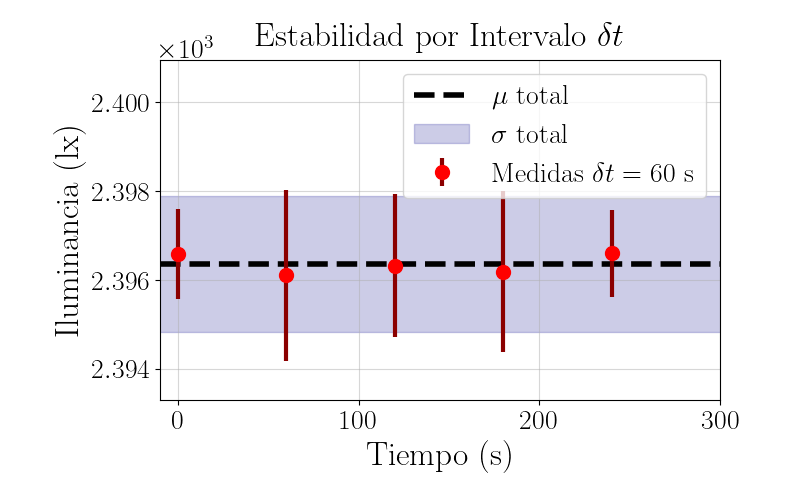

In [5]:
mean_illuminance = np.mean(estabilidad["Illuminance (lx)"])
std_illuminance = np.std(estabilidad["Illuminance (lx)"])

plt.figure(figsize=(8, 5))
plt.axhline(
    y=mean_illuminance, color="black", linestyle="--", lw=4, label=rf"$\mu$ total"
)
plt.fill_between(
    [-100, 400],
    mean_illuminance - std_illuminance,
    mean_illuminance + std_illuminance,
    color="darkblue",
    alpha=0.2,
    label=rf"$\sigma$ total",
)

plt.errorbar(
    resultados_intervalos["Tiempo (s)"],
    resultados_intervalos["Promedio Iluminancia (lx)"],
    yerr=resultados_intervalos["Desviación Estándar (lx)"],
    fmt="o",
    color="red",
    markersize=10,
    ecolor="#8B0000",
    capsize=0,
    elinewidth=3,
    label=rf"Medidas $\delta t=$ {intervalo} s",
)
plt.xlabel("Tiempo (s)")
plt.ylabel("Iluminancia (lx)")
plt.title("Estabilidad por Intervalo $\delta t$")
plt.xlim(-10, 300)
plt.ylim(mean_illuminance - 2 * std_illuminance, mean_illuminance + 3 * std_illuminance)
plt.legend()
plt.savefig(f"particiones_{intervalo}s.pdf")
plt.show()

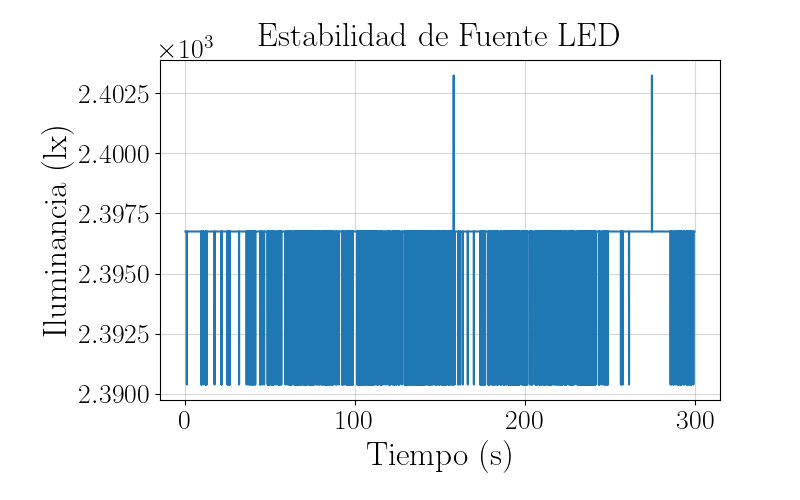

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(estabilidad['Time (s)'], estabilidad['Illuminance (lx)'], label='Illuminance')
plt.xlabel('Tiempo (s)')
plt.ylabel('Iluminancia (lx)')
plt.title('Estabilidad de Fuente LED')
#plt.xlim(0, 300)
#plt.ylim(estabilidad['Illuminance (lx)'].min(), estabilidad['Illuminance (lx)'].max())
plt.savefig("estabilidad_fuente_led.pdf")
plt.show()

### Análisis teórico

Para determinar el tipo de fuente de luz, se empleó únicamente el analizador, inicialmente colocado a 0° y girado hasta 360°. En intervalos de 5°, se midió la intensidad luminosa con el sensor del teléfono celular, registrando el tiempo correspondiente para cada posición.


Dado que la intensidad luminosa es proporcional a:

$$
\begin{align*}
I \propto \cos^2(\theta)
\end{align*}
$$

y dado que la expansión en serie de Taylor alrededor de un punto $\theta_0$ es:

In [11]:

# Definición de variables
x = sp.Symbol('x', real=True)
x0 = sp.Symbol('x0', real=True)

# Función y expansión en serie de Taylor de cos²(x) alrededor de x0
f = sp.cos(x) ** 2
taylor_expansion = sp.series(f, x, x0, 5)  # Expansión hasta orden 4

print(f"La función en LaTeX es: {sp.latex(f)}")
print(f"La expansión en serie en LaTeX es: {sp.latex(taylor_expansion)}")


AttributeError: module 'simpy' has no attribute 'Symbol'

$$
\begin{align*}
\cos^2\theta &= \cos^{2}{\left(x_{0} \right)} - 2 \left(x - x_{0}\right) \sin{\left(x_{0} \right)} \cos{\left(x_{0} \right)} + \left(x - x_{0}\right)^{2} \left(\frac{\sin^{2}{\left(x_{0} \right)}}{\cos^{2}{\left(x_{0} \right)}} - 1\right) \cos^{2}{\left(x_{0} \right)} + \\
 &\frac{4 \left(x - x_{0}\right)^{3} \sin{\left(x_{0} \right)} \cos{\left(x_{0} \right)}}{3} + \left(x - x_{0}\right)^{4} \left(- \frac{\sin^{2}{\left(x_{0} \right)}}{3 \cos^{2}{\left(x_{0} \right)}} + \frac{1}{3}\right) \cos^{2}{\left(x_{0} \right)} + O\left(\left(x - x_{0}\right)^{5}; x\rightarrow x_{0}\right)
\end{align*}
$$

Por lo que cuando $\theta_0 = \frac{\pi}{4}$ entonces:

$$
\cos^2(\theta)_{\theta_0 = \pi/4} \approx \frac{1}{2} - (\theta - \pi/4) + \frac{2}{3}(\theta - \pi/4)^3
$$

Y para $\theta$ alrededor de $\pi/4$:

$$
\cos^2(\theta) \approx \frac{1}{2} - (\theta - \pi/4)
$$


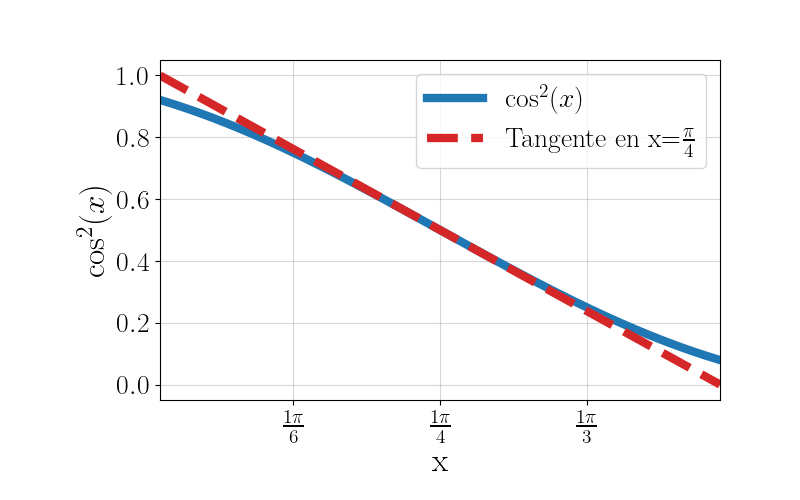

In [13]:
import math

# Graficar cos^2(x) y sus rectas tangentes en los puntos solicitados
xs = np.linspace(0, 2 * np.pi, 300)
f_vals = np.cos(xs) ** 2

puntos = [np.pi / 4]
latex_simbol = [
    r"$\frac{\pi}{4}$",
    r"$\frac{3\pi}{4}$",
    r"$\frac{5\pi}{4}$",
    r"$\frac{7\pi}{4}$",
]

plt.figure(figsize=(8, 5))
plt.plot(xs, f_vals, label=rf"$\cos^2(x)$", lw=6)

for p in puntos:
    y_p = np.cos(p) ** 2
    d_p = -2 * np.cos(p) * np.sin(p)  # Derivada de cos^2(x)

    # Generar la recta tangente alrededor de p
    t_x = np.linspace(p - 0.5, p + 0.5, 50)
    t_y = y_p + d_p * (t_x - p)

    # Buscar el índice correcto para evitar errores de precisión
    index_p = next(i for i, val in enumerate(puntos) if abs(val - p) < 1e-6)

    plt.plot(
        t_x,
        t_y,
        "--",
        label=rf"Tangente en x={latex_simbol[index_p]}",
        lw=6,
        color=colors[3],
        markeredgewidth=20,
        markeredgecolor="yellow",
    )

# Configurar los ejes
plt.xlim(0, 2 * np.pi)
ticks = np.arange(0, 2 * np.pi + np.pi / 12, np.pi / 12)
labels = []

for i, val in enumerate(ticks):
    if i == 0:
        labels.append(r"$0$")
    elif i == 24:  # 2π
        labels.append(r"$2\pi$")
    else:
        g = math.gcd(int(i), 12)
        num = i // g
        den = 12 // g
        if num == 1 and den == 1:
            labels.append(r"$\pi$")
        elif den == 1:
            labels.append(r"$" + f"{num}\\pi" + "$")
        else:
            labels.append(r"$" + f"\\frac{{{num}\\pi}}{{{den}}}" + "$")

plt.xticks(ticks, labels)
plt.xlabel("x")
plt.ylabel(r"$\cos^2(x)$")
plt.legend()
plt.xlim(np.pi / 4 - 0.5, np.pi / 4 + 0.5)
plt.savefig("cos2_tangente.pdf")
plt.show()

### Malus

Compruebo la Ley de Malus para el sensor lumínico

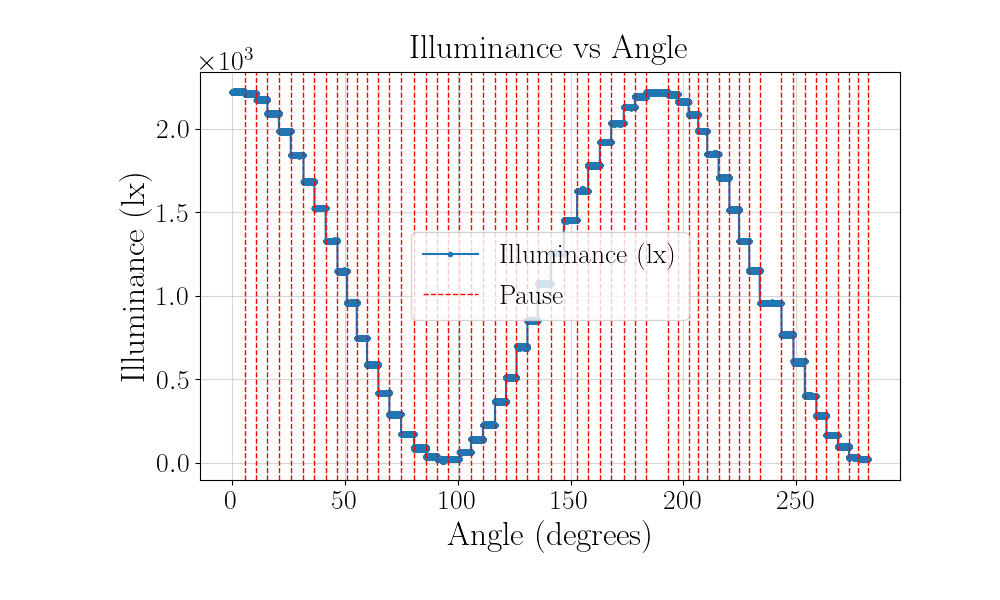

In [14]:
malus_lineal = pd.read_csv("Malus_sensor/Raw Data.csv")
fig, ax = plt.subplots(figsize=(10, 6))
malus_lineal.plot(x='Time (s)', y='Illuminance (lx)', kind='line', marker='.', ax=ax)
ax.set_xlabel('Angle (degrees)')
ax.set_ylabel('Illuminance (lx)')
ax.set_title('Illuminance vs Angle')
# Load the time.csv file
time_data = pd.read_csv("Malus_sensor/meta/time.csv")

# Filter the points where "event" is "PAUSE"
# Filter the points where "event" is "PAUSE" and remove points 188 and 238
# Filter the points where "event" is "PAUSE" and remove points approximately 188 and 238
pause_times = time_data[(time_data["event"] == "PAUSE")]["experiment time"]
pause_times = pause_times.drop([73, 95])

# Plot vertical lines at each pause time
for pause_time in pause_times:
    plt.axvline(x=pause_time, color='red', linestyle='--', linewidth=1, label='Pause' if pause_time == pause_times.iloc[0] else "")

# Add legend
plt.legend()
plt.show()

El valor óptimo de I0 es: 2243.5100813013237
El valor de R^2 es: 0.9995912653457508


NameError: name 'estadisticas_pause_times' is not defined

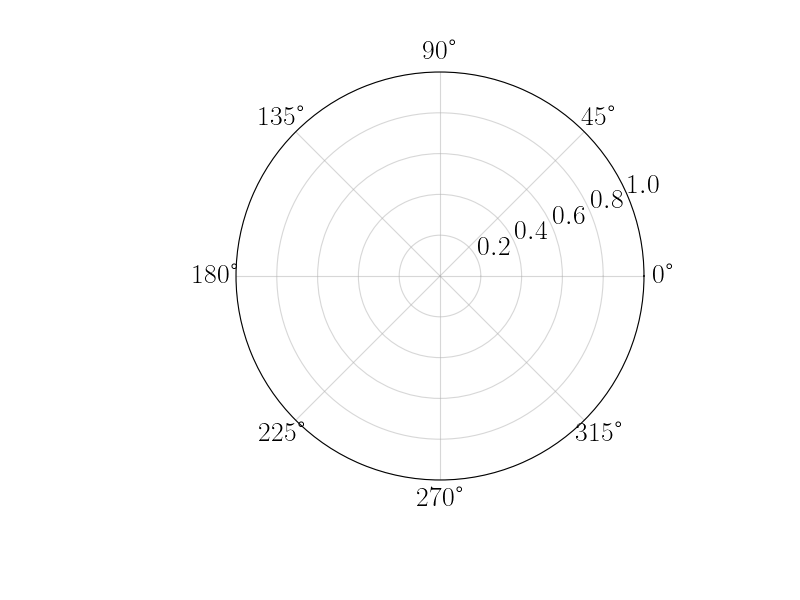

In [23]:
def ajuste(theta, I0):
    return I0 * np.cos(theta)**2

# Ajustar la curva a la función ajuste

# Convertir grados a radianes para el ajuste
grados_radianes = np.radians(stats_df['grados'])

# Ajustar la curva
popt, pcov = curve_fit(ajuste, grados_radianes, stats_df['mean'])
I0_opt = popt[0]
print(f"El valor óptimo de I0 es: {I0_opt}")

# Generar datos ajustados
ajuste_vals = ajuste(grados_radianes, I0_opt)
# Calcular R^2
residuals = stats_df['mean'] - ajuste_vals
ss_res = np.sum(residuals**2)
ss_tot = np.sum((stats_df['mean'] - np.mean(stats_df['mean']))**2)
r_squared = 1 - (ss_res / ss_tot)
print(f"El valor de R^2 es: {r_squared}")


# Crear la figura y los ejes
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 6))

# Graficar los promedios de iluminancia con barras de error
estadisticas_pause_times['grados'] = np.radians(np.linspace(0, 270, num=estadisticas_pause_times.shape[0]))
ax.errorbar(
    estadisticas_pause_times['grados'],
    estadisticas_pause_times['promedio_iluminancia'],
    yerr=estadisticas_pause_times['desviacion_estandar'],
    fmt='o',
    ecolor='darkblue',
    markersize=6,
    capsize=0,
    fillstyle='none',  # Ensure markers are not filled
    markeredgewidth=2,  # Increase the border thickness
    label='Luminancia (lx)'
)

# Graficar la curva ajustada
ax.plot(grados_radianes, ajuste_vals, label=f'Ajuste', color='red', lw=3, linestyle='--')
# Añadir el texto en la gráfica
ax.text(0.65, 0.3, f'$R^2 = {r_squared:.4f}$', transform=ax.transAxes, fontsize=20, verticalalignment='top', bbox=dict(facecolor='white', alpha=1))

# Configurar etiquetas y título
ax.set_title('Ley de Malus - Sensor de Luz')
ax.legend(loc='upper center')
ax.set_rlabel_position(270)
# Guardar la gráfica en un archivo PDF
fig.savefig("sensor_malus.png")
# Mostrar la gráfica
plt.show()


In [24]:
df = datos_linealidad_sensor.copy()
df.columns = ["x", "y"]

# Supongamos que tu DataFrame se llama df con columnas 'x' y 'y'
# Ordenamos por 'x' (por si acaso los datos no están ordenados)
df = df.sort_values(by="x")

# Detectar los puntos donde la señal "salta" usando diferencias finitas
threshold = 50  # Umbral para detectar los saltos (ajustar según los datos)
jumps = np.where(np.abs(np.diff(df["y"])) > threshold)[0]  # Índices de los saltos

# Agregar los extremos inicial y final
intervals = np.concatenate(([0], jumps + 1, [len(df)]))

# Calcular promedio y desviación estándar en cada segmento
stats = []
for i in range(len(intervals) - 1):
    y_segment = df["y"].iloc[intervals[i]:intervals[i + 1]]
    mean_y = np.mean(y_segment)
    std_y = np.std(y_segment)
    stats.append({"mean": mean_y, "std": std_y})

# Convertir a DataFrame
stats_df = pd.DataFrame(stats)


# Crear la nueva columna con valores de 20 a 70
new_column = np.linspace(20, 70, num=stats_df.shape[0])

# Añadir la nueva columna al DataFrame
stats_df.insert(0, 'grados', new_column)
# Mostrar resultados
print(stats_df)

    grados         mean       std
0     20.0  1975.885009  3.045366
1     25.0  1842.244516  1.740727
2     30.0  1681.531668  0.773269
3     35.0  1499.930939  2.614187
4     40.0  1308.024803  0.975334
5     45.0  1114.307632  1.386541
6     50.0   941.314499  2.001584
7     55.0   747.570458  1.110078
8     60.0   579.899485  0.398190
9     65.0   412.382772  0.222459
10    70.0   282.797075  2.018640


Como se puede ver en la anterior figura existe un rango lineal alrededor de cada $\pi/4 + n\pi/2$, en particular entre 20° y 70°, podemos ver la una pequeña desviación, con errores dados por la siguiente gráfica:

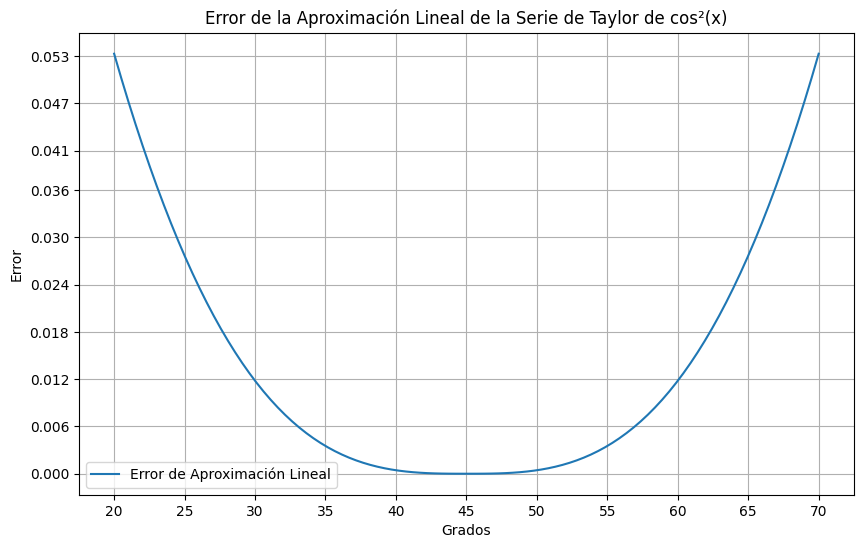

In [ ]:
# Definir la función original y la aproximación lineal
def cos2(x):
    return np.cos(x)**2

def taylor_approx(x):
    return 0.5 - (x - np.pi/4)

# Convertir grados a radianes
degrees = np.linspace(20, 70, 100)
radians = np.radians(degrees)

# Calcular el error
error = np.abs(cos2(radians) - taylor_approx(radians))

# Graficar el error
plt.figure(figsize=(10, 6))
plt.plot(degrees, error, label='Error de Aproximación Lineal')
plt.xlabel('Grados')
plt.ylabel('Error')
plt.xticks(np.arange(20, 71, 5))
plt.yticks(np.round(np.linspace(0, max(error), 10), 3))
plt.title('Error de la Aproximación Lineal de la Serie de Taylor de cos²(x)')
plt.grid(True)
plt.legend()
plt.show()

Se observó un error máximo de 5.3×10⁻² (equivalente a 5.3%). Para determinar la linealidad del sensor, se empleó un analizador y un polarizador, ubicando el polarizador a 0° y rotando el analizador de 20° a 70° en pasos de 5°. Se midió la intensidad luminosa con el sensor de un teléfono celular, registrando el tiempo correspondiente para cada posición.


### Polarización Linterna

In [ ]:
# Importar los datos
datosSensorConAnalizador = pd.read_excel(
    r"PolarizacionLinterna\intento2\Luz_2025_01_15_16_34_25.xls"
)
# Filtrar los datos entre x=3.8 y x=40
filtered_data = datosSensorConAnalizador[(datosSensorConAnalizador['Time (s)'] >= 3) & (datosSensorConAnalizador['Time (s)'] <= 43.5)].copy()

# Ya no se va a usar
# datos_stop = pd.read_excel(
#     r"PolarizacionLinterna\intento2\Luz_2025_01_15_16_34_25.xls", sheet_name="stop"
# )


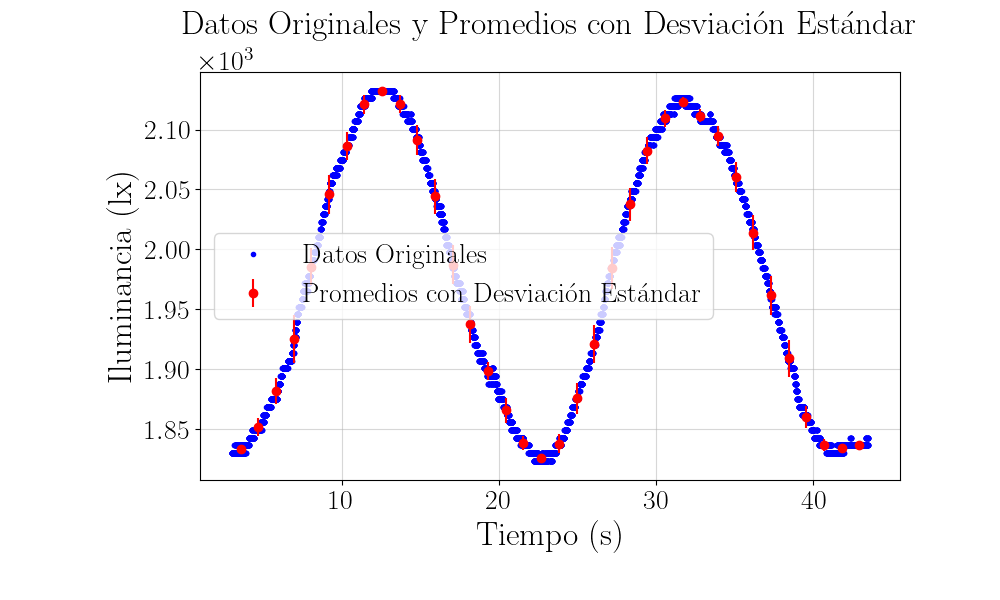

In [68]:
# Estrategia: dividir la gráfica total
# Dividir los datos en 36 partes
num_parts = 36
filtered_data['part'] = pd.cut(filtered_data['Time (s)'], bins=num_parts, labels=False)

# Calcular promedio y desviación estándar para cada parte
promedios = filtered_data.groupby('part')['Illuminance (lx)'].mean()
desviaciones = filtered_data.groupby('part')['Illuminance (lx)'].std()
# Crear el DataFrame con los promedios, desviaciones y grados
pol_linterna = pd.DataFrame({
    'Grados': np.linspace(10, 360, num=num_parts),
    'Promedio Iluminancia (lx)': promedios,
    'Desviación Estándar (lx)': desviaciones
})

# Obtener los tiempos correspondientes a cada parte
tiempos = filtered_data.groupby('part')['Time (s)'].mean()

# Graficar los datos originales y los puntos promedio con barras de error
plt.figure(figsize=(10, 6))
plt.plot(filtered_data['Time (s)'], filtered_data['Illuminance (lx)'], 'b.', label='Datos Originales')
plt.errorbar(tiempos, promedios, yerr=desviaciones, fmt='ro', label='Promedios con Desviación Estándar')
plt.xlabel('Tiempo (s)')
plt.ylabel('Iluminancia (lx)')
plt.title('Datos Originales y Promedios con Desviación Estándar')
plt.legend()
plt.show()

1563.393633527292
0.5166389720393808


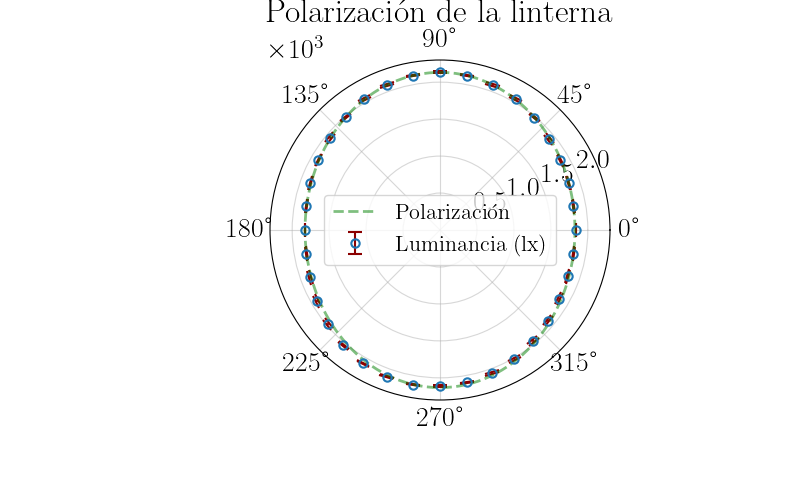

In [124]:
# Convert degrees to radians for the polar plot
pol_linterna["Grados_rad"] = np.radians(pol_linterna["Grados"])

# Create a polar plot
fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(8, 5))

# Plot the data with error bars
ax.errorbar(
    pol_linterna["Grados_rad"],
    pol_linterna["Promedio Iluminancia (lx)"],
    yerr=pol_linterna["Desviación Estándar (lx)"],
    fmt="o",
    ecolor="darkred",
    capsize=5,
    label="Luminancia (lx)",
    fillstyle="none",
    markersize=6,
    markeredgewidth=1.5,
)  # Increased markeredgewidth to 2


# Obtener los valores mínimos y máximos de la iluminancia
min_illuminance = pol_linterna["Promedio Iluminancia (lx)"].min()
max_illuminance = pol_linterna["Promedio Iluminancia (lx)"].max()

# Parámetros de la elipse
a = max_illuminance  # Semieje mayor
b = min_illuminance  # Semieje menor
theta = np.linspace(0, 2*np.pi, 300)  # Ángulo de 0 a 2pi

# Ecuaciones de la elipse en coordenadas polares
excentricidad = np.sqrt(a**2 - b**2)/a
r = (a * b) / np.sqrt((b * np.cos(theta + np.pi/2))**2 + (a * np.sin(theta + np.pi/2))**2)
print(b**2/a)
print(np.sqrt(1-(b**2/a**2)))
# Graficar la elipse
ax.plot(theta, r, linestyle="--", color="green", linewidth=2, label="Polarización", alpha = 0.5)

# Set the title and labels
ax.set_title("Polarización de la linterna", pad=10)
#fig.subplots_adjust(top=0.85)

# Add a legend
ax.legend(loc="center", fontsize=16)
# Set the y-axis limit
ax.set_ylim(0, 2.3e3)
# Show the plot
plt.savefig("polarizacion_linterna.png")
plt.show()

In [130]:
pol_linterna[pol_linterna['Promedio Iluminancia (lx)'] == max_illuminance]['Desviación Estándar (lx)'].iloc[0]

0.0

In [125]:
# Parámetros de ajuste de la elipse
max_degree = pol_linterna[pol_linterna['Promedio Iluminancia (lx)'] == max_illuminance]['Grados'].iloc[0]
excentricidad = np.sqrt(max_illuminance**2 - min_illuminance**2)/max_illuminance
print(max_degree, excentricidad, max_illuminance, min_illuminance, sep='\n')

90.0
0.5166389720393809
2132.625
1825.9606643356644


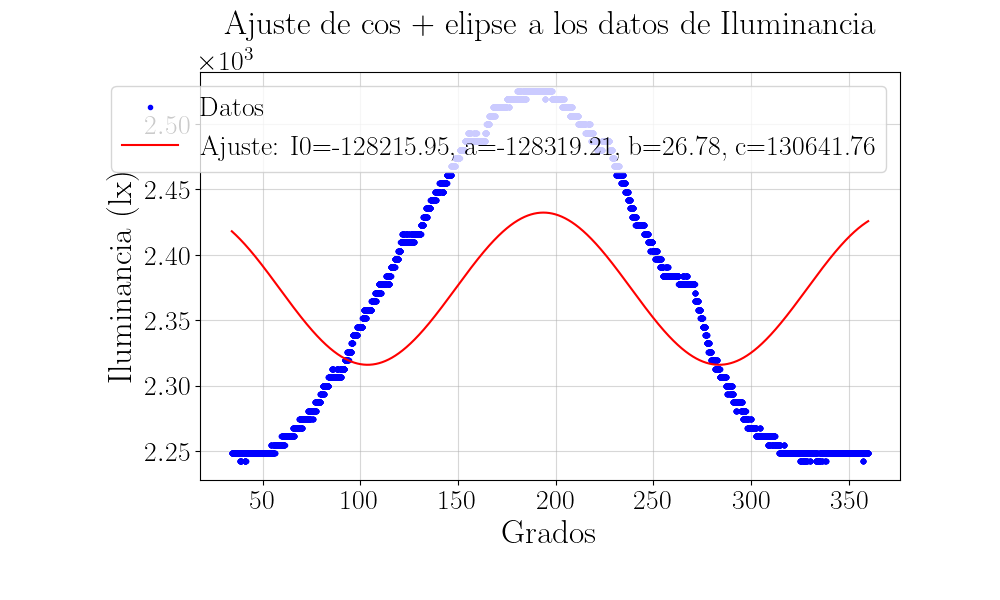

In [ ]:
# Ajustar la curva cos^2 + elipse
def cos2_elipse(x, I0, a, b, c):
    return I0 * np.cos(np.radians(x))**2 + a * b / (1 - b * np.cos(theta - c))

# Convertir los tiempos a grados (suponiendo que el tiempo está en segundos y corresponde a grados)
filtered_data.loc[:, 'Grados'] = filtered_data['Time (s)'] * (360 / 40)  # Ajustar según la relación tiempo-grados

# Ajustar la curva
popt, pcov = curve_fit(cos2_elipse, filtered_data['Grados'], filtered_data['Illuminance (lx)'], p0=[I0_opt, 1, 1, 1])
I0_opt, a_opt, b_opt, c_opt = popt

# Generar datos ajustados
ajuste_vals = cos2_elipse(filtered_data['Grados'], I0_opt, a_opt, b_opt, c_opt)

# Plot the data and the fit
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(filtered_data['Grados'], filtered_data['Illuminance (lx)'], 'b.', label='Datos')
ax.plot(filtered_data['Grados'], ajuste_vals, 'r-', label=f'Ajuste: I0={I0_opt:.2f}, a={a_opt:.2f}, b={b_opt:.2f}, c={c_opt:.2f}')
ax.set_xlabel('Grados')
ax.set_ylabel('Iluminancia (lx)')
ax.set_title('Ajuste de cos + elipse a los datos de Iluminancia')
ax.legend()
plt.show()

## Análisis y Resultados


### Polarización de la luz de la fuente (cristian)


#### Tratamiento de datos


In [ ]:
# Filtrar datos donde "Time (s)" coincide con los valores de tcada5 (dentro de un margen pequeño)
def filtrar_por_tiempos(df, tiempos, margen=0.0015):
    filtro = df["Time (s)"].apply(lambda t: any(abs(t - tiempo) <= margen for tiempo in tiempos))
    return df[filtro]

def remove_repeated_intensities(df):
        return df.drop_duplicates(keep='first')

#### Datos


In [ ]:
# Lista de tiempos seleccionados
tcada5 = [
    0,1.86,  2.66,  3.63,  4.66,  5.82,  6.88,  7.87,  8.79, 9.59, 
    10.52, 11.42, 12.45, 13.37, 14.30, 15.24, 16.24, 17.11, 18.08,
    19.02, 19.90, 20.77, 21.68, 22.72, 23.59, 24.51, 25.37, 26.30,
    27.29, 28.14, 29.05, 30.04, 31.12
]

print(len(tcada5))

# Carga de datos desde el archivo xls
datosSensorConAnalizador = pd.read_excel(
    "PolarizacionLinterna/Luz_2025_01_15_16_21_58.xls"
)



# Aplicar filtro
datos_filtrados = filtrar_por_tiempos(datosSensorConAnalizador, tcada5)
datos_filtrados.loc[:, "Time (s)"] = datos_filtrados["Time (s)"].round(2)

datos_filtrados = remove_repeated_intensities(datos_filtrados)

# Mostrar resultados
print(datos_filtrados)

len(datos_filtrados["Illuminance (lx)"])


33
       Time (s)  Illuminance (lx)
0          0.00          2248.625
704        1.86          2255.000
1009       2.66          2248.625
1379       3.63          2242.125
1771       4.66          2248.625
2213       5.82          2248.625
2617       6.88          2261.500
2994       7.87          2274.375
3345       8.79          2287.250
3649       9.59          2306.625
4004      10.52          2325.875
4347      11.42          2358.125
4739      12.45          2377.500
5090      13.37          2403.250
5444      14.30          2416.125
5802      15.24          2441.875
6183      16.24          2461.250
6515      17.11          2487.000
6884      18.08          2487.000
7242      19.02          2512.750
7578      19.90          2519.250
7909      20.77          2525.625
8256      21.68          2525.625
8652      22.72          2512.750
8984      23.59          2499.875
9334      24.51          2487.000
9662      25.37          2480.500
10016     26.30          2448.375
10394     2

33

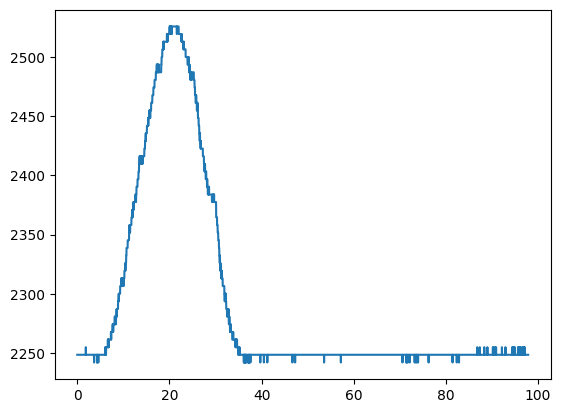

In [ ]:
plt.plot(datosSensorConAnalizador["Time (s)"], datosSensorConAnalizador["Illuminance (lx)"], label="Original")

33


Text(0.5, 1.0, 'Distribución de Iluminancia')

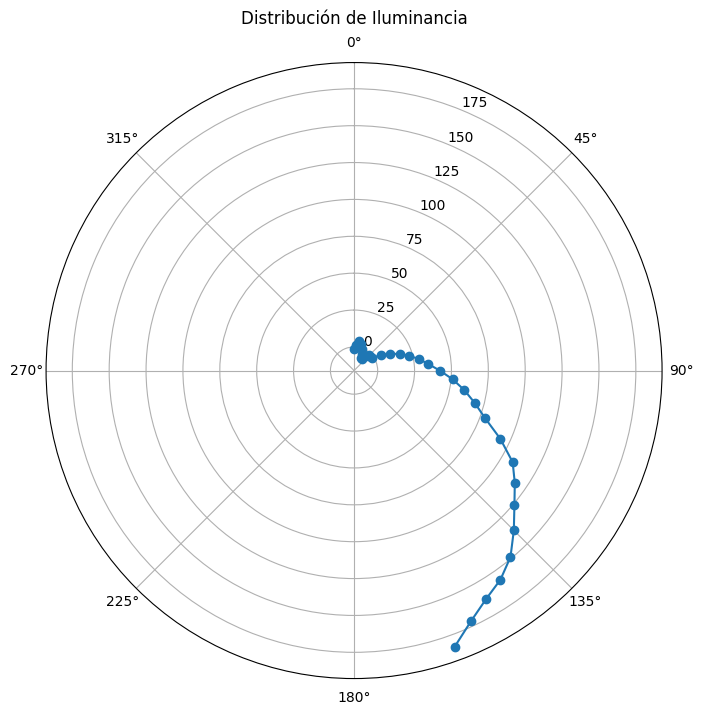

In [ ]:
# Obtener las columnas necesarias para la gráfica
iluminancias_filtradas = datos_filtrados["Illuminance (lx)"].values - 2250

# Generar ángulos para la gráfica polar (5 a 160 grados, con 5 grados de separación)
angulos = np.radians(np.arange(0, 165, 5))

print(len(angulos))

# Interpolar las iluminancias al rango de ángulos
iluminancias_interpoladas = np.interp(
    angulos, np.linspace(0, 2 * np.pi, len(iluminancias_filtradas), endpoint=False), iluminancias_filtradas
)

# Graficar en coordenadas polares
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))
ax.plot(angulos, iluminancias_interpoladas, marker='o')

# Configurar ejes
ax.set_theta_zero_location("N")  # Norte en la parte superior
ax.set_theta_direction(-1)  # Sentido horario
ax.set_title("Distribución de Iluminancia", va='bottom')

#### Intento 2

In [ ]:
tCada10 = [
    0.83, 1.79, 2.61, 3.57, 4.56, 5.62, 6.68, 7.88, 9.09, 10.25, 
    11.26, 12.28, 13.18, 14.07, 14.99, 16.06, 17.62, 18.83, 19.92, 20.91, 
    21.96, 22.99, 24.00, 24.96, 25.86, 26.95, 28.18, 29.34, 30.50, 31.68, 
    32.68, 33.67, 34.68, 35.71, 36.71, 38.36
]

print(len(tCada10))

# Carga de datos desde el archivo xls
datosSensorConAnalizadorIntento2 = pd.read_excel(
    "PolarizacionLinterna/intento2/Luz_2025_01_15_16_34_25.xls"
)


# Aplicar filtro
datos_filtrados2 = filtrar_por_tiempos(datosSensorConAnalizadorIntento2, tCada10,margen=0.002)
datos_filtrados2.loc[:, "Time (s)"] = datos_filtrados2["Time (s)"].round(2)
datos_filtrados2 = remove_repeated_intensities(datos_filtrados2)

# Mostrar resultados
print(datos_filtrados2)

len(datos_filtrados2["Illuminance (lx)"])

36
       Time (s)  Illuminance (lx)
307        0.83          1829.750
673        1.79          1829.750
985        2.61          1836.250
1351       3.57          1829.750
1728       4.56          1849.125
2132       5.62          1874.875
2536       6.68          1907.125
2993       7.88          1971.500
3454       9.09          2042.375
3896      10.25          2087.500
4281      11.26          2119.750
4669      12.28          2132.625
5012      13.18          2132.625
5352      14.07          2113.250
5702      14.99          2081.125
6110      16.06          2036.000
6704      17.62          1958.625
7165      18.83          1907.125
7580      19.92          1874.875
7958      20.91          1849.125
8358      21.96          1829.750
8750      22.99          1829.750
9135      24.00          1842.750
9501      24.96          1874.875
9844      25.86          1913.625
10259     26.95          1971.500
10728     28.18          2036.000
11170     29.34          2081.125
11612     3

36

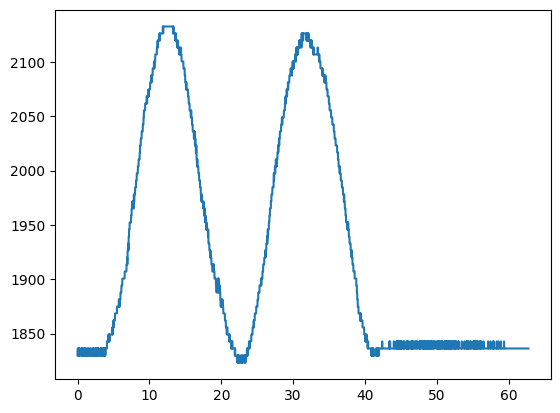

In [ ]:
plt.plot(datosSensorConAnalizadorIntento2["Time (s)"], datosSensorConAnalizadorIntento2["Illuminance (lx)"], label="Original")


36


Text(0.5, 1.0, 'Distribución de Iluminancia')

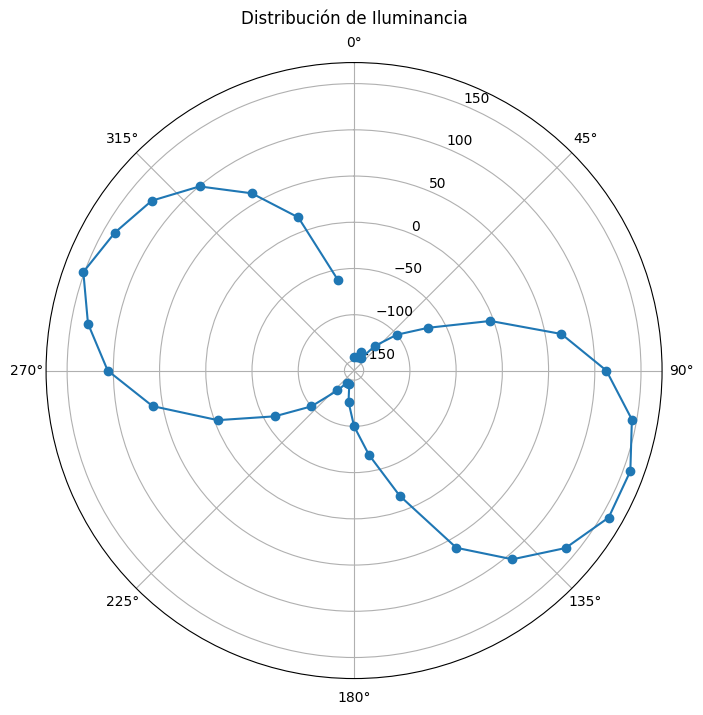

In [ ]:
# Obtener las columnas necesarias para la gráfica
iluminancias_filtradas2 = datos_filtrados2["Illuminance (lx)"].values - 1975

# Generar ángulos para la gráfica polar (5 a 160 grados, con 5 grados de separación)
angulos2 = np.radians(np.arange(0, 360, 10))

print(len(angulos2))

# Interpolar las iluminancias al rango de ángulos
iluminancias_interpoladas2 = np.interp(
    angulos2, np.linspace(0, 2 * np.pi, len(iluminancias_filtradas2), endpoint=False), iluminancias_filtradas2
)

# Graficar en coordenadas polares
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))
ax.plot(angulos2, iluminancias_interpoladas2, marker='o')

# Configurar ejes
ax.set_theta_zero_location("N")  # Norte en la parte superior
ax.set_theta_direction(-1)  # Sentido horario
ax.set_title("Distribución de Iluminancia", va='bottom')

### Linealidad del sensor 

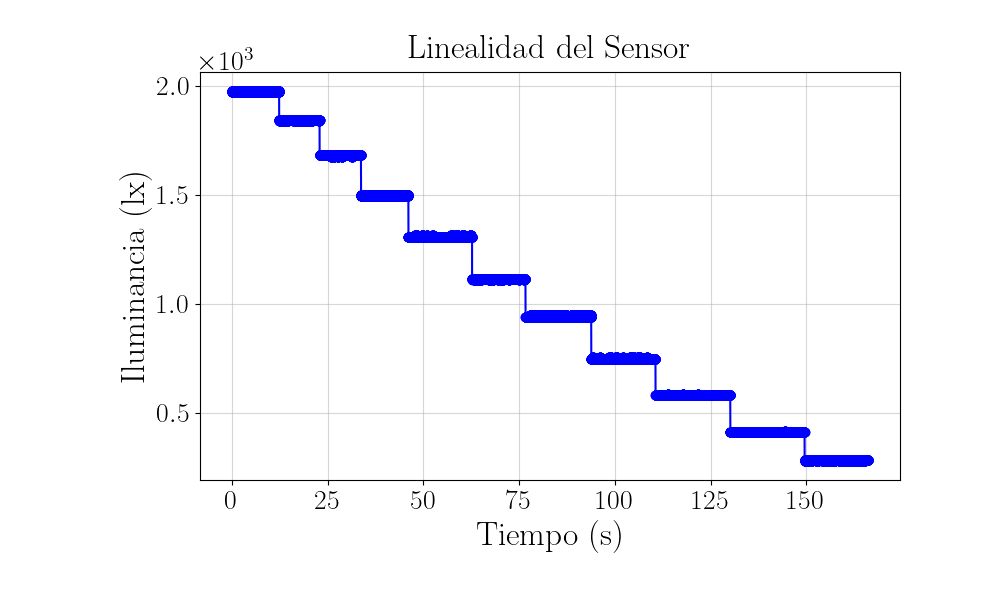

In [19]:
# Cargar datos desde el archivo Excel
datos_linealidad_sensor = pd.read_excel("Linealidad_Sensor/Luz_2025_01_15_17_38_10.xls")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(datos_linealidad_sensor["Time (s)"], datos_linealidad_sensor["Illuminance (lx)"], marker='o', linestyle='-', color='b')
ax.set_title("Linealidad del Sensor")
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Iluminancia (lx)")
plt.show()

In [18]:
df = pd.read_excel("Linealidad_Sensor/Luz_2025_01_15_17_38_10.xls")
df.columns = ["x", "y"]

# Supongamos que tu DataFrame se llama df con columnas 'x' y 'y'
# Ordenamos por 'x' (por si acaso los datos no están ordenados)
df = df.sort_values(by="x")

# Detectar los puntos donde la señal "salta" usando diferencias finitas
threshold = 50  # Umbral para detectar los saltos (ajustar según los datos)
jumps = np.where(np.abs(np.diff(df["y"])) > threshold)[0]  # Índices de los saltos

# Agregar los extremos inicial y final
intervals = np.concatenate(([0], jumps + 1, [len(df)]))

# Calcular promedio y desviación estándar en cada segmento
stats = []
for i in range(len(intervals) - 1):
    y_segment = df["y"].iloc[intervals[i]:intervals[i + 1]]
    mean_y = np.mean(y_segment)
    std_y = np.std(y_segment)
    stats.append({"mean": mean_y, "std": std_y})

# Convertir a DataFrame
stats_df = pd.DataFrame(stats)


# Crear la nueva columna con valores de 20 a 70
new_column = np.linspace(20, 70, num=stats_df.shape[0])

# Añadir la nueva columna al DataFrame
stats_df.insert(0, 'grados', new_column)
# Mostrar resultados
print(stats_df)


    grados         mean       std
0     20.0  1975.885009  3.045366
1     25.0  1842.244516  1.740727
2     30.0  1681.531668  0.773269
3     35.0  1499.930939  2.614187
4     40.0  1308.024803  0.975334
5     45.0  1114.307632  1.386541
6     50.0   941.314499  2.001584
7     55.0   747.570458  1.110078
8     60.0   579.899485  0.398190
9     65.0   412.382772  0.222459
10    70.0   282.797075  2.018640


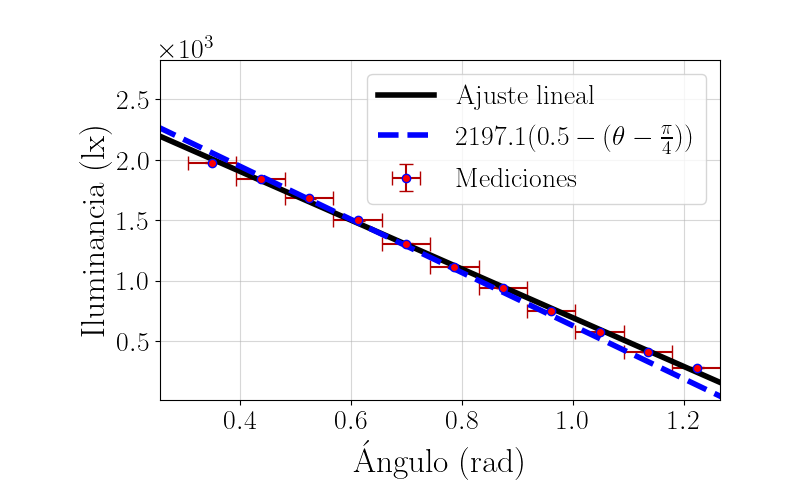

In [20]:
# Read the CSV file
data = stats_df.copy()
fig, ax = plt.subplots(figsize=(8, 5))
# Assuming the CSV has columns 'x', 'y', and 'yerr' for x values, y values, and y errors respectively
x = np.radians(range(20, 75, 5))
y = data["mean"]
xerr = np.radians(2.5)
yerr = data["std"]

# Create the plot
ax.errorbar(
    x,
    y,
    xerr=xerr,
    yerr=yerr,
    fmt="o",
    ecolor="#b20000",
    mfc="red",
    mec="blue",
    capsize=5,
    label="Mediciones",
)

# Perform linear regression
slope, intercept = np.polyfit(x, y, 1)
regression_line = slope * x + intercept

# Plot the regression line
ax.axline((0, intercept), slope=slope, label=f"Ajuste lineal", color="black", lw=4)


# Plot approximation 0.5 - (x - np.pi/4)
def taylor_approx(x, I):
    return I * (0.5 - (x - np.pi / 4))


# Fit the parameter I
popt, pcov = curve_fit(taylor_approx, x, y)
I_opt = popt[0]

# Plot the approximation with the fitted parameter
# Extend the range of x for extrapolation
x_extended = np.linspace(x.min() - 0.1, x.max() + 0.1, 100)
ax.plot(
    x_extended,
    taylor_approx(x_extended, I_opt),
    label=rf"${I_opt:.1f}(0.5 - (\theta - \frac{{\pi}}{{4}}))$",
    color="blue",
    linestyle="--",
    lw=4,
)

# Add labels and title
ax.set_xlabel("Ángulo (rad)")
ax.set_ylabel("Iluminancia (lx)")
ax.legend()
# Set the x and y limits to only show the data
ax.set_xlim([0.255, 1.264])
ax.set_ylim([15, 2826])
# Save the plot with a resolution of 400 DPI
plt.savefig('plot_linealidad_sensor.pdf')
plt.show()

11


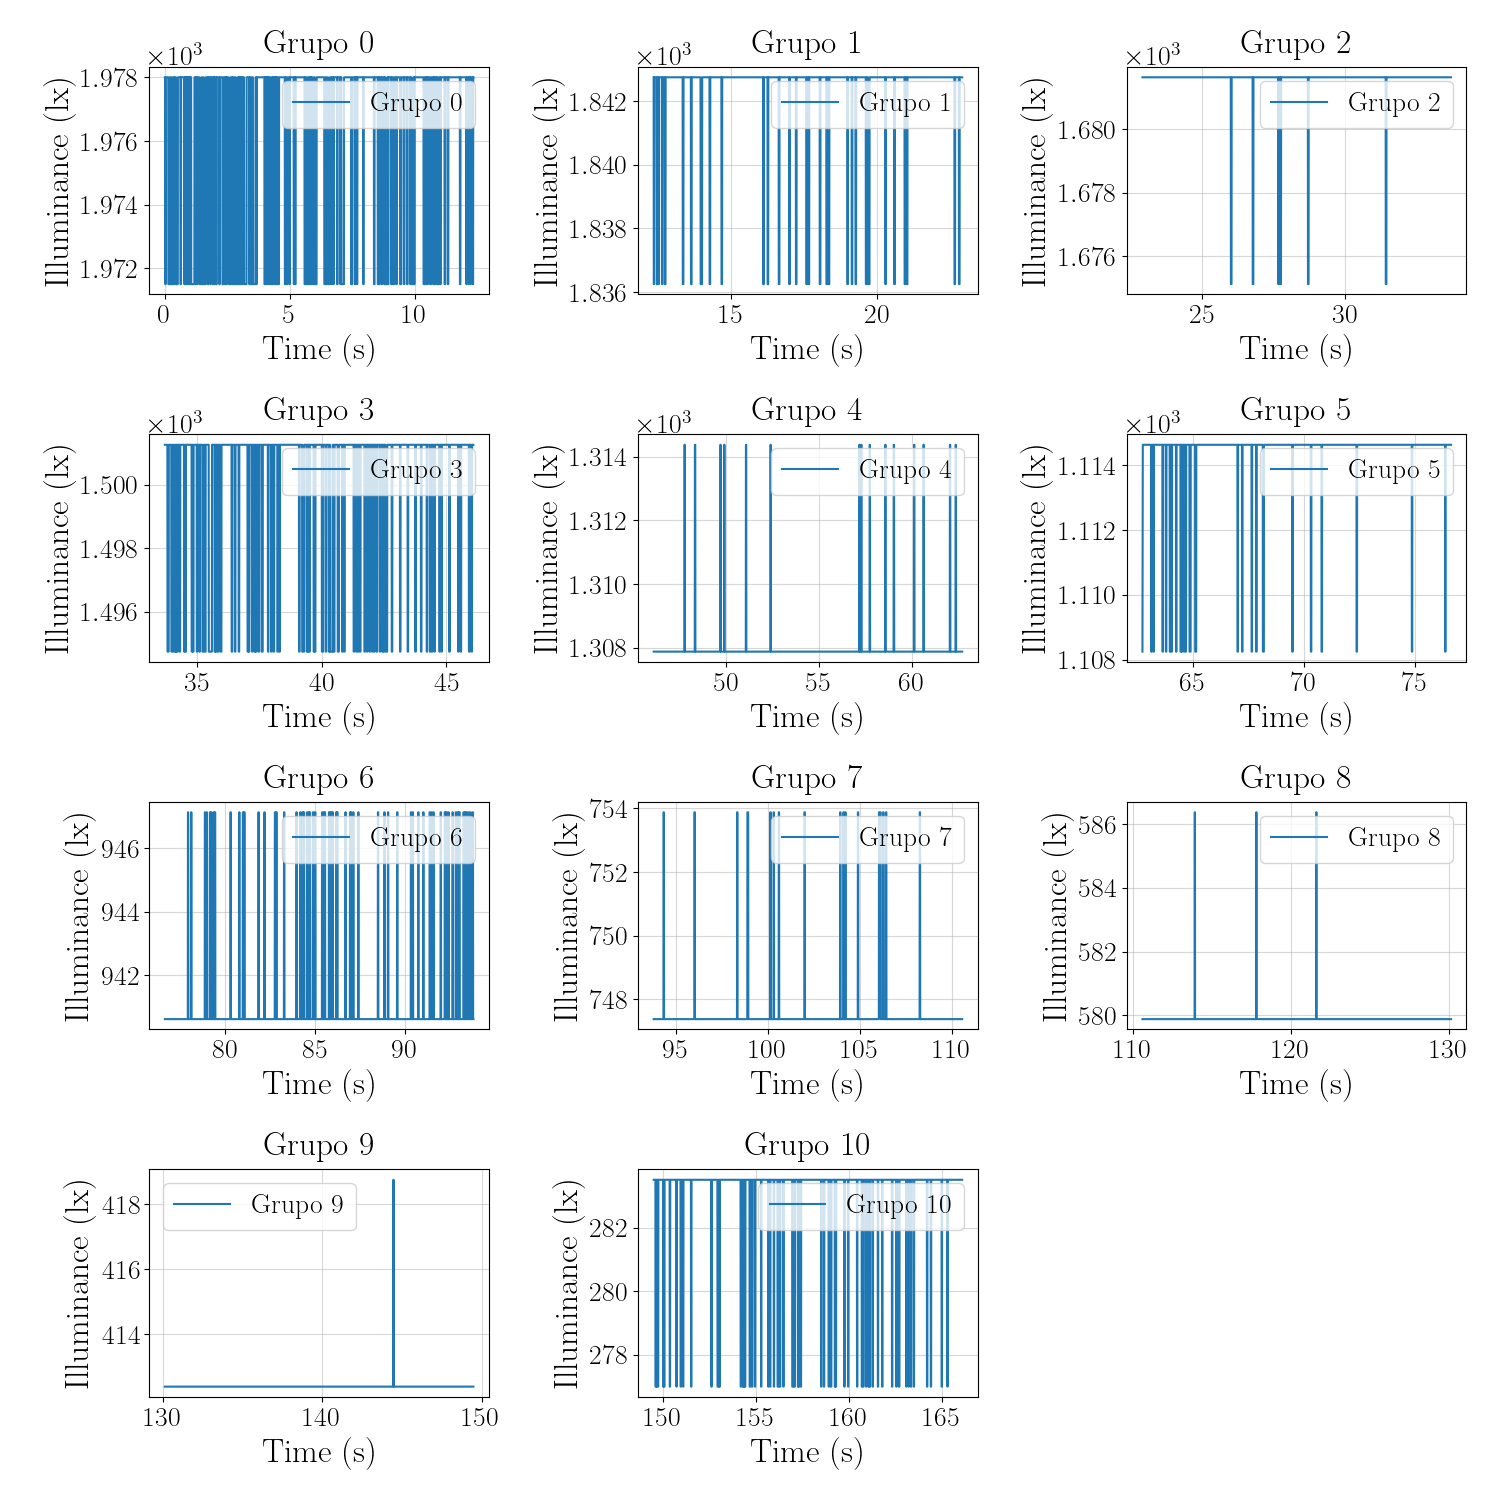

[1975.8850085178876, 1842.244516450648, 1681.5316682891214, 1499.9309392265193, 1308.0248026835043, 1114.3076324721856, 941.3144994642583, 747.5704581049334, 579.8994854029329, 412.3827722839339, 282.7970750988142]


In [21]:
# Cargar los datos desde tu archivo Excel
datos_linealidad_sensor = pd.read_excel("Linealidad_Sensor/Luz_2025_01_15_17_38_10.xls")

# Asegúrate de identificar las columnas correctas. Supongamos que son "Time (s)" e "Illuminance (lx)"
# Ajusta los nombres de las columnas según el archivo Excel.
df = datos_linealidad_sensor[['Time (s)', 'Illuminance (lx)']].copy()

# Definir el umbral para detectar cambios significativos en la iluminancia
umbral_salto = 50  # Ajusta según el comportamiento esperado de tus datos

# Calcular la diferencia absoluta en iluminancia
df['diff_iluminancia'] = df['Illuminance (lx)'].diff().abs()

# Identificar saltos significativos
df['es_salto'] = df['diff_iluminancia'] > umbral_salto

# Asignar un identificador de grupo para cada segmento
df['grupo'] = df['es_salto'].cumsum()

# Dividir los datos en subconjuntos basados en el grupo
grupos = [g for _, g in df.groupby('grupo')]

print(len(grupos))

# # Visualizar los resultados o procesar cada grupo por separado
# for i, grupo in enumerate(grupos):
#     print(f"\n===== Grupo {i} =====")
#     print(grupo[['Time (s)', 'Illuminance (lx)']])
#     # Si necesitas guardar cada grupo como un archivo Excel o CSV:
#     grupo.to_csv(f"grupo_{i}.csv", index=False)


fig, axs = plt.subplots(4, 3, figsize=(15, 15))
axs = axs.flatten()

for i, grupo in enumerate(grupos):
    axs[i].plot(grupo["Time (s)"], grupo["Illuminance (lx)"], label=f"Grupo {i}")
    axs[i].set_title(f"Grupo {i}")
    axs[i].set_xlabel("Time (s)")
    axs[i].set_ylabel("Illuminance (lx)")
    axs[i].legend()
    axs[i].grid(True)

# Eliminar las subfiguras vacías
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()


# Calcular el promedio de la intensidad en cada grupo
promedios_intensidad = [grupo['Illuminance (lx)'].mean() for grupo in grupos]

# Mostrar los promedios
print(promedios_intensidad)

[20 25 30 35 40 45 50 55 60 65 70]
Pendiente: -35.20220810524219
Intersección: 2710.089260917239
Coeficiente de correlación: -0.9992647186204208
Valor p: 4.6344509667647306e-14
Error estándar: 0.45022544124293895


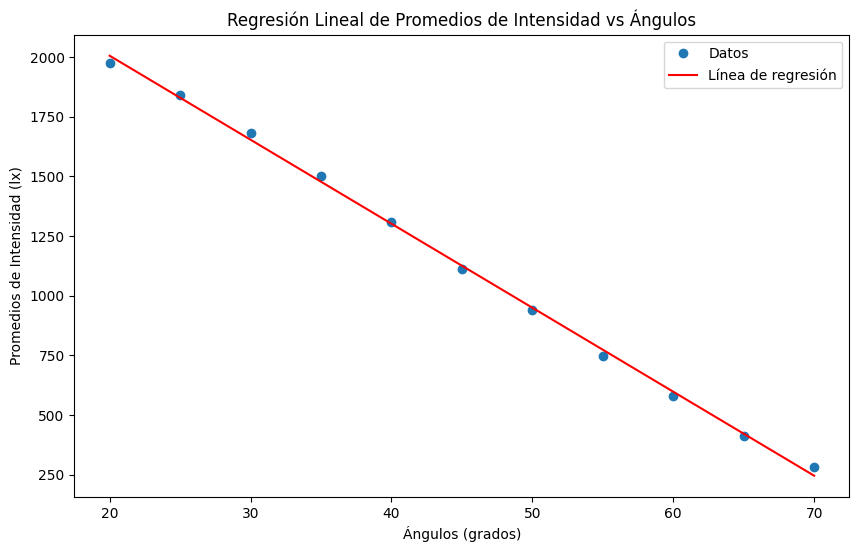

In [ ]:
angulos = np.arange(20, 75, 5)
print(angulos)
# Realizar la regresión lineal# Realizar la regresión lineal# Realizar la regresión lineal
slope, intercept, r_value, p_value, std_err = stats.linregress(angulos, promedios_intensidad)

# Mostrar los resultados de la regresión
print(f"Pendiente: {slope}")
print(f"Intersección: {intercept}")
print(f"Coeficiente de correlación: {r_value}")
print(f"Valor p: {p_value}")
print(f"Error estándar: {std_err}")

# Graficar los datos y la línea de regresión
plt.figure(figsize=(10, 6))
plt.plot(angulos, promedios_intensidad, 'o', label='Datos')
plt.plot(angulos, intercept + slope * angulos, 'r', label='Línea de regresión')
plt.xlabel('Ángulos (grados)')
plt.ylabel('Promedios de Intensidad (lx)')
plt.title('Regresión Lineal de Promedios de Intensidad vs Ángulos')
plt.legend()
slope, intercept, r_value, p_value, std_err = stats.linregress(angulos, promedios_intensidad)


## Conclusiones

### 2. Describa el estado de polarización de la luz de la linterna después de pasar por el primer polarizador y después de pasar por el segundo polarizador cuando este último está rotado un ángulo arbitrario entre 0° y 360°.

### 3. Entregue las gr´aficas de sus experimentos en el orden propuesto en la secci´on ”Durante la clase.

### 4. Para la ley de Malus, corrija sus datos en caso de que la respuesta de su detector/c´amara no sea lineal. Compare los gr´aficos que obtuvo para la ley de Malus y discuta las diferencias entre los resultados de: sensor vs c´amara, y, c´amara-regi´on vs c´amara-pixe